# RMD Motor PID Tuning

## 1. Imports

In [13]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Finding R

Read the latest file (by sorting filename) into a dataframe.

In [14]:
files = glob.glob('data/exp_R_*.csv')
files.sort()
latest_file = files[-1]

print(f"Reading file: '{latest_file}'")
df = pd.read_csv(latest_file)
df

Reading file: 'data/exp_R_2025-12-16T1703.csv'


,exp,Kp,u,t,i
0,0,1.0,5.0,0.000003,0.13
1,0,1.0,5.0,0.008007,0.14
2,0,1.0,5.0,0.012000,0.01
3,0,1.0,5.0,0.016046,0.04
4,0,1.0,5.0,0.020099,-0.06
...,...,...,...,...,...
49349,99,5.0,10.0,1.982520,7.98
49350,99,5.0,10.0,1.986550,8.00
49351,99,5.0,10.0,1.990251,7.81
49352,99,5.0,10.0,1.994579,8.00


### 2.1. Linearisation

Setting $K_i = 0$ and observing step response, we can find armature resistance R:
$$ R = K_p \left( \frac{u}{I_{ss}} - 1\right ) $$

Linearising:
$$ \frac{u}{I_{ss}} = R \left( \frac{1}{K_p} \right) + 1 $$

$$ \implies Y = \frac{u}{I_{ss}}, X = \frac{1}{K_p} $$

For each experiment, a step input reference current was set at time t=1.0s with feedback current recorded from t=0.0s to t=2.0s.

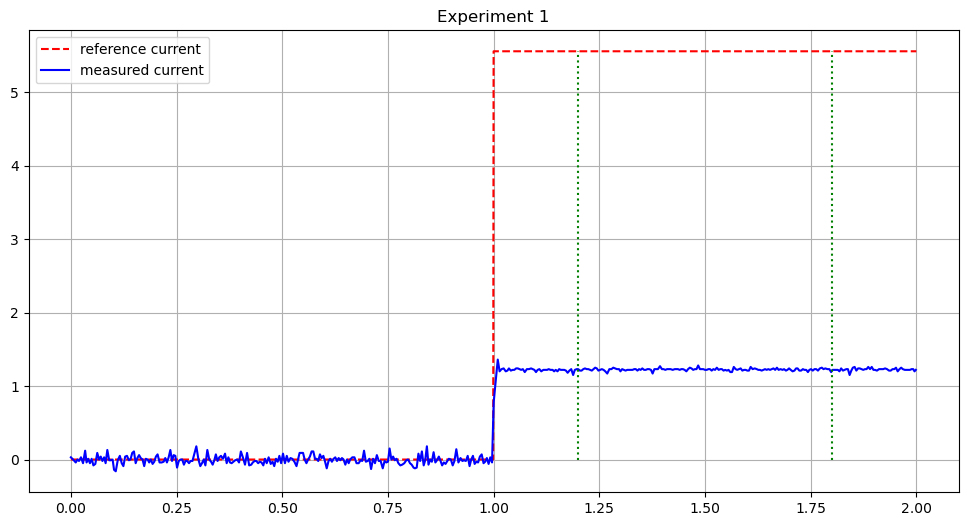

In [15]:
exp = 1
tmp_df = df[df['exp'] == exp]

plt.figure(figsize=(12,6))

u = tmp_df.iloc[0]['u']
plt.title(f"Experiment {exp}")
plt.plot([0,0.999,1,2], [0,0,u,u], 'r--', label='reference current')
plt.plot(tmp_df['t'], tmp_df['i'], 'b-', label='measured current')
plt.vlines(1.2, 0, u, 'g', 'dotted')
plt.vlines(1.8, 0, u, 'g', 'dotted')
plt.grid(True)
plt.legend()

Find the mean of samples between 1.2s < t < 1.8s to obtain Iss.

In [16]:
df_cropped = df[(1.2 < df['t']) & (df['t'] < 1.8)]
df_iss = df_cropped.groupby('exp').agg({
	'Kp': 'first',
	'u': 'first',
	'i': 'mean',
}).reset_index().rename(columns={'i': 'iss'})
df_iss

,exp,Kp,u,iss
0,0,1.0,5.000000,0.977718
1,1,1.0,5.555556,1.224762
2,2,1.0,6.111111,1.495333
3,3,1.0,6.666667,1.797200
4,4,1.0,7.222222,2.111611
...,...,...,...,...
95,95,5.0,7.777778,6.158200
96,96,5.0,8.333333,6.614267
97,97,5.0,8.888889,7.070323
98,98,5.0,9.444444,7.532603


Calculate $Y = \frac{u}{I_{ss}}$ and $X = \frac{1}{K_p}$.

In [17]:
df_lin = pd.DataFrame()
df_lin['X'] = 1 / df_iss['Kp']
df_lin['Y'] = df_iss['u'] / df_iss['iss']
df_lin

,X,Y
0,1.0,5.113948
1,1.0,4.536029
2,1.0,4.086789
3,1.0,3.709474
4,1.0,3.420243
...,...,...
95,0.2,1.262995
96,0.2,1.259903
97,0.2,1.257211
98,0.2,1.253809


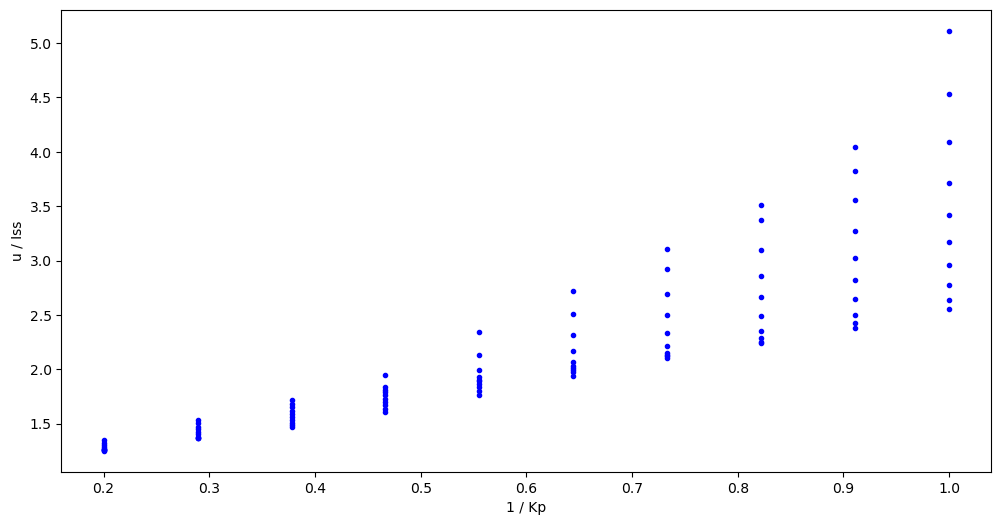

In [18]:
plt.figure(figsize=(12,6))

plt.plot(df_lin['X'], df_lin['Y'], 'b.')
plt.xlabel('1 / Kp')
plt.ylabel('u / Iss');

The trend doesn't look very linear.

Try a linear regressor anyway:

In [19]:
r_lin, intercept = np.polyfit(df_lin['X'], df_lin['Y'], 1)
print(f"Estimated R:  {r_lin:.6f}")
print(f"Intercept:    {intercept:.6f}")

Estimated R:  2.673536
Intercept:    0.580615


Results not very good. Try curve fitting with $I_{ss} = \frac{K_p u}{R + K_p}$ where $K_p, u$ are inputs and $I_{ss}$ is output and $R$ is to be optimised.

In [20]:
from scipy.optimize import curve_fit

def system_model_R(inputs, r):
	kp, u = inputs
	return (kp * u) / (r + kp)

init_guess = [r_lin]
popt, pcov = curve_fit(system_model_R, (df_iss['Kp'], df_iss['u']), df_iss['iss'], p0=init_guess)
r_nonlin = popt[0]
err = np.sqrt(np.diag(pcov))[0]

print(f"Estimated R:  {r_nonlin:.6f} ± {err:.6f}")

Estimated R:  1.650962 ± 0.034992


Looks better, now plot the results.

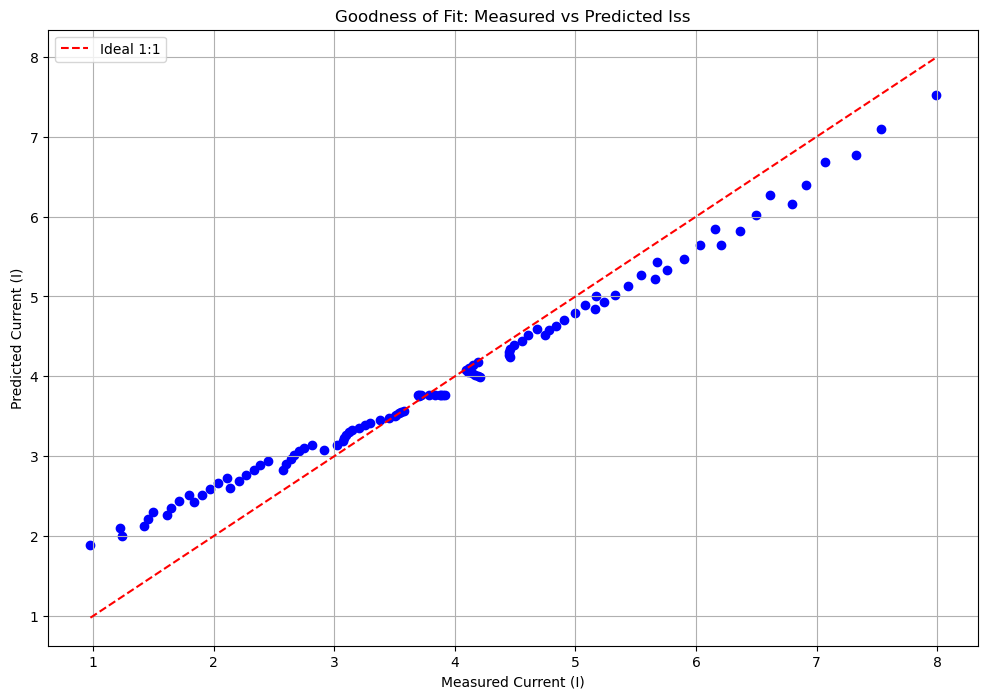

In [21]:
plt.figure(figsize=(12,8))

real_y = df_iss['iss']
pred_y = system_model_R((df_iss['Kp'], df_iss['u']), r_nonlin)
plt.scatter(real_y, pred_y, color='b')
plt.plot([min(real_y), max(real_y)], [min(real_y), max(real_y)], 'r--', label='Ideal 1:1')
plt.title('Goodness of Fit: Measured vs Predicted Iss')
plt.xlabel('Measured Current (I)')
plt.ylabel('Predicted Current (I)')
plt.legend()
plt.grid(True)

Clearly there is uncaptured physics in the system model. Try including offsets in $u$ and $I$:

$$ \begin{aligned}
I_{meas} &= I_{true} + I_{off} \\
u_{meas} &= u_{true} + u_{off} \\
\\
I_{true} &= \frac{K_p \cdot u_{true}}{R + K_p}
\end{aligned} $$

In [22]:
def system_model_Ro(inputs, r, u_off, i_off):
	kp, u_meas = inputs
	u_true = u_meas - u_off
	iss_true = (kp * u_true) / (r + kp)
	iss_pred = iss_true + i_off
	return iss_pred

init_guess = [r_nonlin, 0, 0]
bounds = ([0, -10, -10], [999, 10, 10])

popt, pcov = curve_fit(
	system_model_Ro,
	(df_iss['Kp'], df_iss['u']),
	df_iss['iss'],
	p0=init_guess,
	bounds=bounds
)
r_wo, u_off, i_off = popt
err_r, err_u, err_i = np.sqrt(np.diag(pcov))

print(f"Estimated R:     {r_wo:.6f} ± {err_r:.6f}")
print(f"Estimated u_off: {u_off:.6f} ± {err_u:.6f}")
print(f"Estimated i_off: {i_off:.6f} ± {err_i:.6f}")

Estimated R:     0.743007 ± 0.013835
Estimated u_off: -4.314818 ± 0.117142
Estimated i_off: -4.417093 ± 0.121286


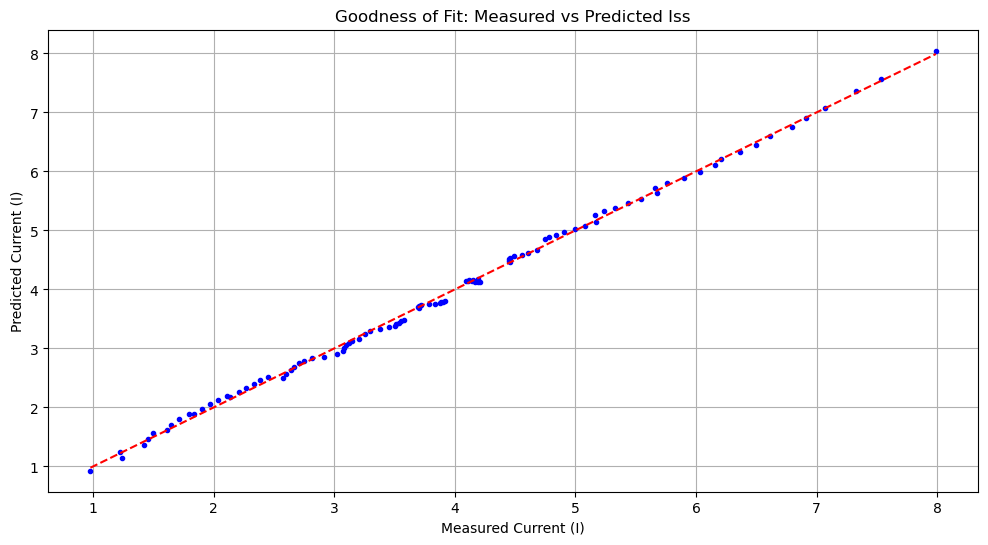

In [23]:
plt.figure(figsize=(12,6))

real_y = df_iss['iss']
pred_y = system_model_Ro((df_iss['Kp'], df_iss['u']), *popt)
plt.plot(real_y, pred_y, 'b.')
plt.plot([min(real_y), max(real_y)], [min(real_y), max(real_y)], 'r--', label='Ideal 1:1')
plt.title('Goodness of Fit: Measured vs Predicted Iss')
plt.xlabel('Measured Current (I)')
plt.ylabel('Predicted Current (I)')
plt.grid(True)

## 3. Finding L

In [24]:
files = glob.glob('data/exp_LR_*.csv')
files.sort()
latest_file = files[-1]

print(f"Reading file: '{latest_file}'")
df = pd.read_csv(latest_file)
df

Reading file: 'data/exp_LR_2025-12-18T1824.csv'


,exp,Ki,u,t,i
0,0,0.0002,5.0,0.000006,2.52
1,0,0.0002,5.0,0.007844,2.50
2,0,0.0002,5.0,0.011807,2.53
3,0,0.0002,5.0,0.015592,2.51
4,0,0.0002,5.0,0.019554,2.51
...,...,...,...,...,...
11272,29,0.0004,10.0,1.483682,9.99
11273,29,0.0004,10.0,1.487457,10.13
11274,29,0.0004,10.0,1.491304,9.85
11275,29,0.0004,10.0,1.495298,10.02


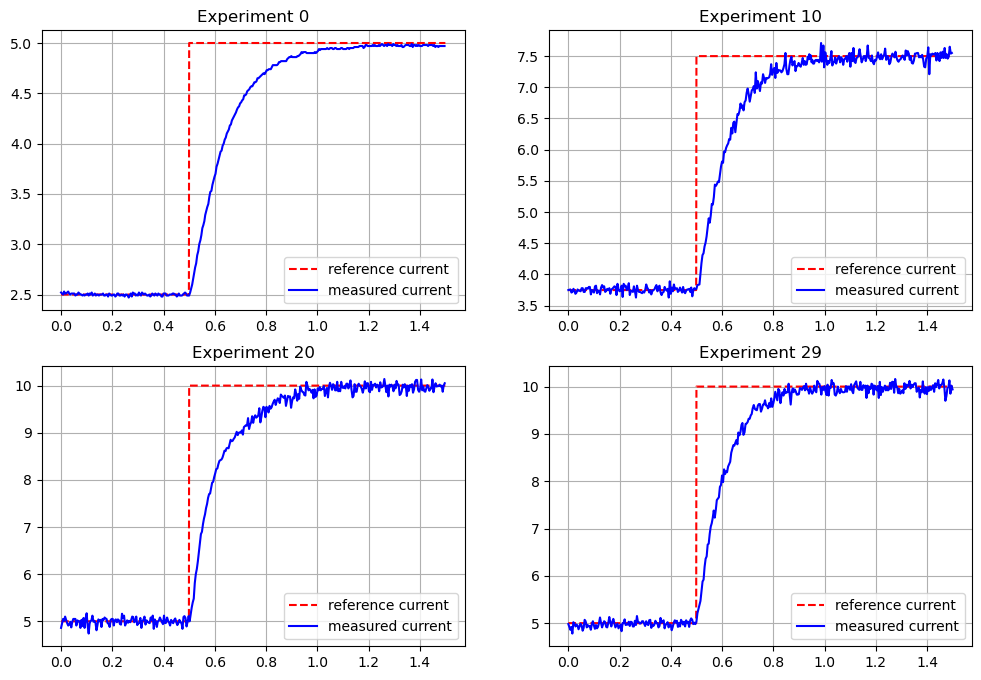

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

def plot_exp(exp: int, axesObj):
	tmp_df = df[df['exp'] == exp]
	u = tmp_df.iloc[0]['u']
	axesObj.set_title(f"Experiment {exp}")
	axesObj.plot([0,0.499,0.5,1.5], [u/2,u/2,u,u], 'r--', label='reference current')
	axesObj.plot(tmp_df['t'], tmp_df['i'], 'b-', label='measured current')
	axesObj.grid(True)
	axesObj.legend()

plot_exp(0, axes[0][0])
plot_exp(10, axes[0][1])
plot_exp(20, axes[1][0])
plot_exp(29, axes[1][1])

Set $t=0$ to start of step input by subtracting 0.5s and discarding $t<0$.

In [26]:
df_trunc_t = pd.DataFrame(df)
df_trunc_t['t'] = df_trunc_t['t'] - 0.5
df_trunc_t = df_trunc_t[df_trunc_t['t'] >= 0]
df_trunc_t

,exp,Ki,u,t,i
125,0,0.0002,5.0,0.003819,2.52
126,0,0.0002,5.0,0.011834,2.60
127,0,0.0002,5.0,0.015806,2.66
128,0,0.0002,5.0,0.019540,2.71
129,0,0.0002,5.0,0.023379,2.77
...,...,...,...,...,...
11272,29,0.0004,10.0,0.983682,9.99
11273,29,0.0004,10.0,0.987457,10.13
11274,29,0.0004,10.0,0.991304,9.85
11275,29,0.0004,10.0,0.995298,10.02


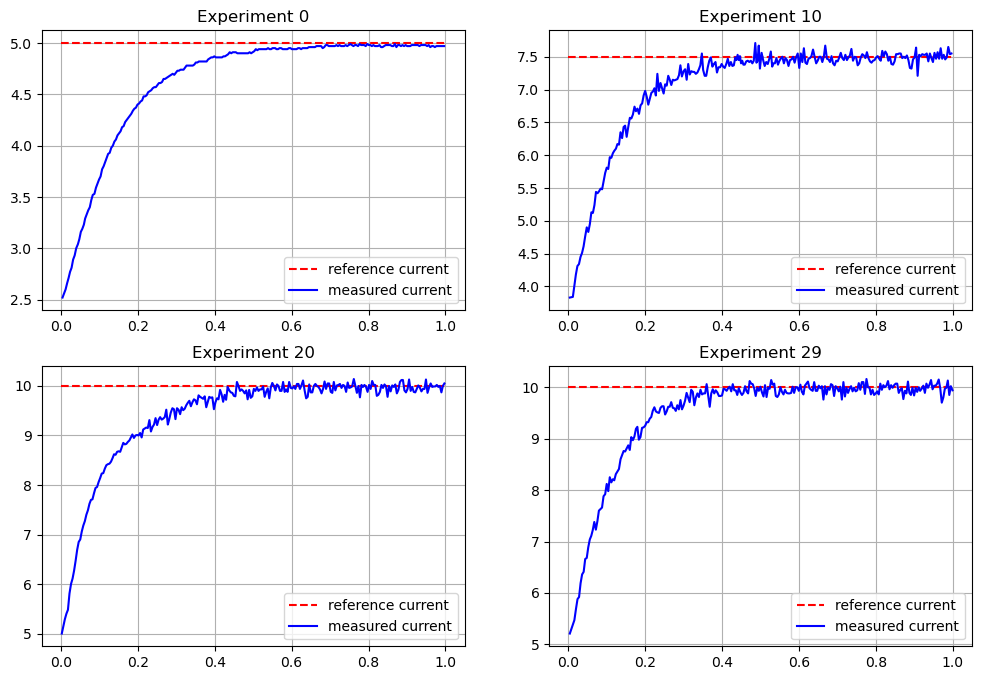

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

def plot_clean_exp(exp: int, axesObj):
	tmp_df = df_trunc_t[df_trunc_t['exp'] == exp]
	u = tmp_df.iloc[0]['u']
	axesObj.set_title(f"Experiment {exp}")
	axesObj.hlines(u, 0, 1, colors='r', linestyles='dashed', label='reference current')
	axesObj.plot(tmp_df['t'], tmp_df['i'], 'b-', label='measured current')
	axesObj.grid(True)
	axesObj.legend()

plot_clean_exp(0,  axes[0][0])
plot_clean_exp(10, axes[0][1])
plot_clean_exp(20, axes[1][0])
plot_clean_exp(29, axes[1][1])

In [28]:
def system_model_LRo(inputs, l, r):
	ki, u, t = inputs
	c0 = u / 2

	w = np.sqrt(ki / l)
	z = r / (2 * np.sqrt(ki * l))

	q = np.sqrt(z*z - 1)
	theta = w * t * q
	return u + (c0 - u) * np.exp(-z*w*t) * (np.cosh(theta) + z/q * np.sinh(theta))

init_guess = [8e-8, 3e-5]
bounds = ([1e-10, 1e-7], [1e-6, 1e-3])

popt, pcov = curve_fit(
	system_model_LRo,
	(df_trunc_t['Ki'], df_trunc_t['u'], df_trunc_t['t']),
	df_trunc_t['i'],
	p0=init_guess,
	bounds=bounds
)
l_pred, r_pred = popt
err_l, err_r = np.sqrt(np.diag(pcov))

print(f"Estimated L: {l_pred:.2e} ± {abs(err_l)/abs(l_pred) * 100:.2f}%")
print(f"Estimated R: {r_pred:.2e} ± {abs(err_r)/abs(r_pred) * 100:.2f}%")

Estimated L: 8.76e-08 ± 9.34%
Estimated R: 3.46e-05 ± 0.19%


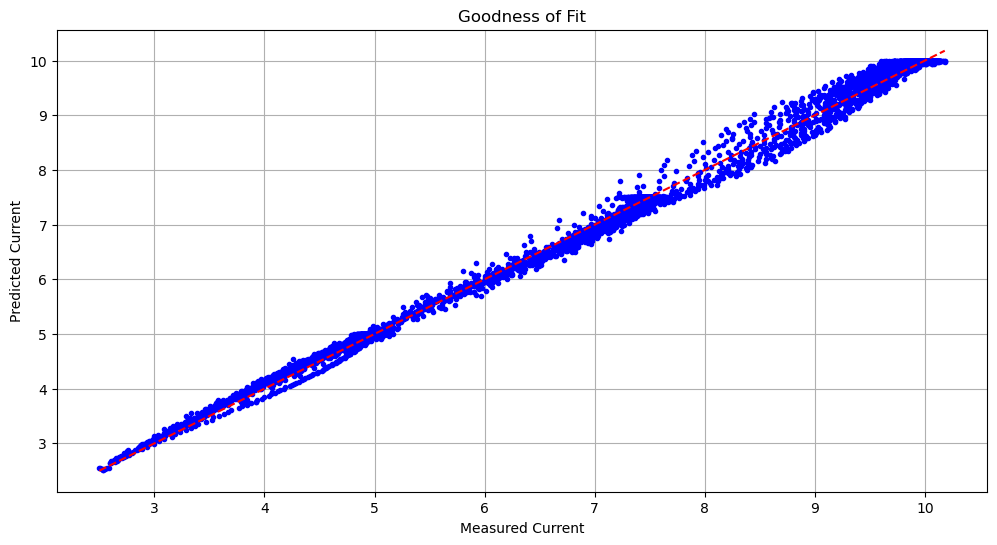

In [29]:
plt.figure(figsize=(12,6))

real_y = df_trunc_t['i']
pred_y = system_model_LRo((df_trunc_t['Ki'], df_trunc_t['u'], df_trunc_t['t']), *popt)
plt.plot(real_y, pred_y, 'b.')
plt.plot([min(real_y), max(real_y)], [min(real_y), max(real_y)], 'r--', label='Ideal 1;1')
plt.title('Goodness of Fit')
plt.xlabel('Measured Current')
plt.ylabel('Predicted Current')
plt.grid(True)

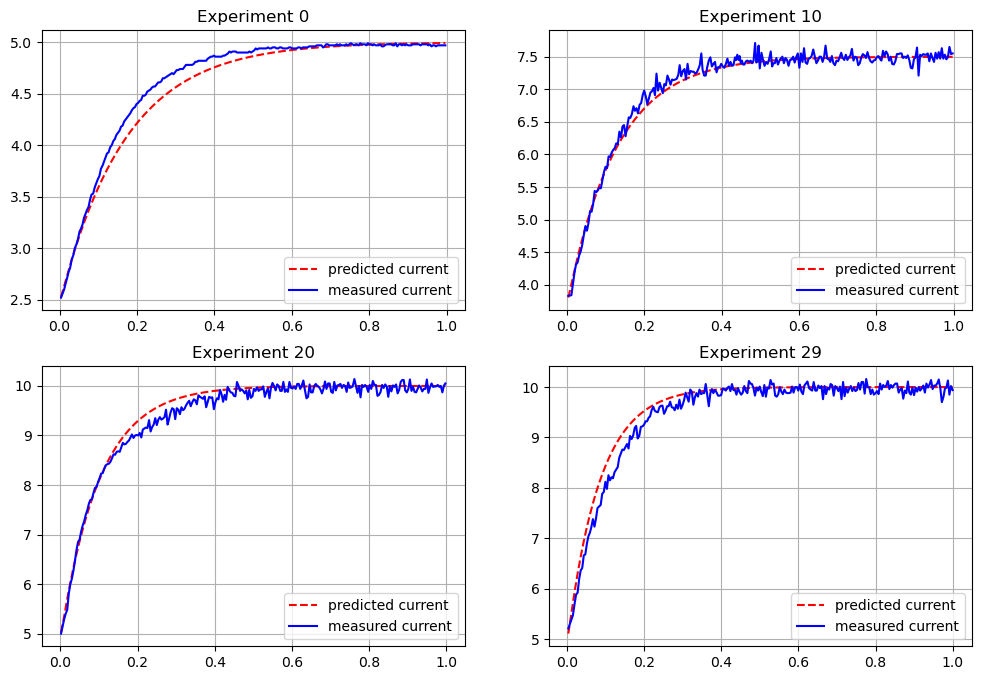

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

def plot_exp_w_model(exp: int, axesObj):
	tmp_df = df_trunc_t[df_trunc_t['exp'] == exp]
	u = tmp_df.iloc[0]['u']
	axesObj.set_title(f"Experiment {exp}")
	model_y = system_model_LRo((tmp_df['Ki'], tmp_df['u'], tmp_df['t']), *popt)
	axesObj.plot(tmp_df['t'], model_y, 'r--', label='predicted current')
	axesObj.plot(tmp_df['t'], tmp_df['i'], 'b-', label='measured current')
	axesObj.grid(True)
	axesObj.legend()

plot_exp_w_model(0,  axes[0][0])
plot_exp_w_model(10, axes[0][1])
plot_exp_w_model(20, axes[1][0])
plot_exp_w_model(29, axes[1][1])